In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df.shape

(7043, 21)

In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [7]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [9]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [10]:
df = df.dropna()

In [11]:
df.isnull().sum().sum()

np.int64(0)

In [12]:
df["Churn"].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [13]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

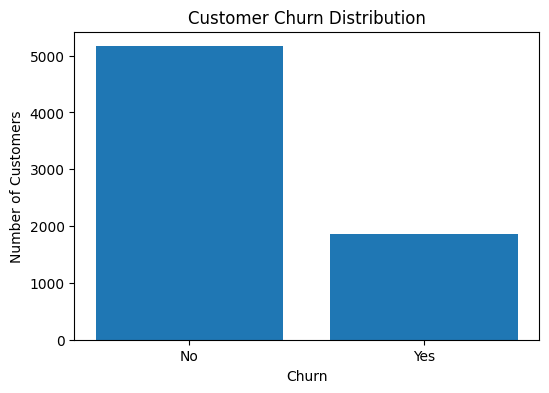

In [14]:
churn_counts = df["Churn"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(churn_counts.index.astype(str), churn_counts.values)
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

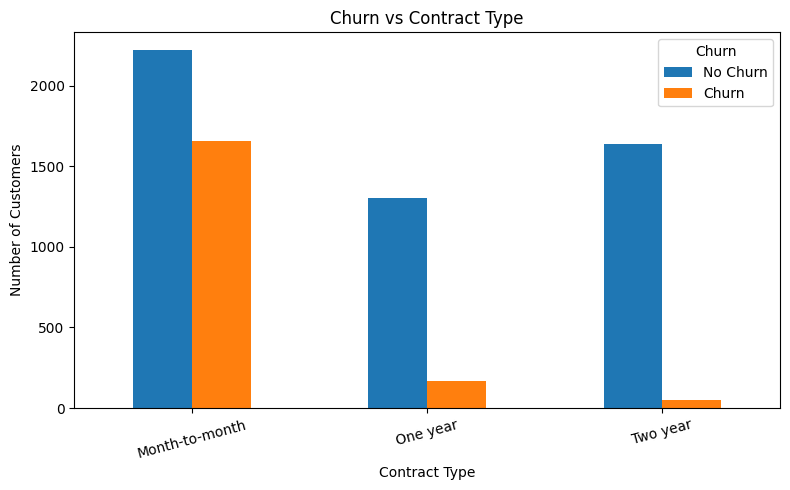

In [15]:
contract_churn = pd.crosstab(df["Contract"], df["Churn"])

contract_churn.plot(kind="bar", figsize=(8,5))
plt.title("Churn vs Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=15)
plt.legend(["No Churn", "Churn"], title="Churn")
plt.tight_layout()
plt.show()

In [16]:
df = df.drop("customerID", axis=1)

In [17]:
df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

In [18]:
categorical_columns = df.select_dtypes(include="object").columns

df = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=True
)

In [19]:
df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False


In [20]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [21]:
print("Features:", X.shape)
print("Target:", y.shape)

Features: (7032, 30)
Target: (7032,)


In [22]:
df["Churn"].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

In [23]:
print(df["Churn"].value_counts(dropna=False))

Churn
0    5163
1    1869
Name: count, dtype: int64


In [24]:
print("NaN in X:", X.isna().sum().sum())
print("NaN in y:", y.isna().sum())

NaN in X: 0
NaN in y: 0


In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (5625, 30)
Testing data: (1407, 30)


## Exploratory Data Analysis — Churn vs Tenure

/tmp/ipykernel_800/3796863821.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(tenure_groups, labels=["No Churn", "Churn"])


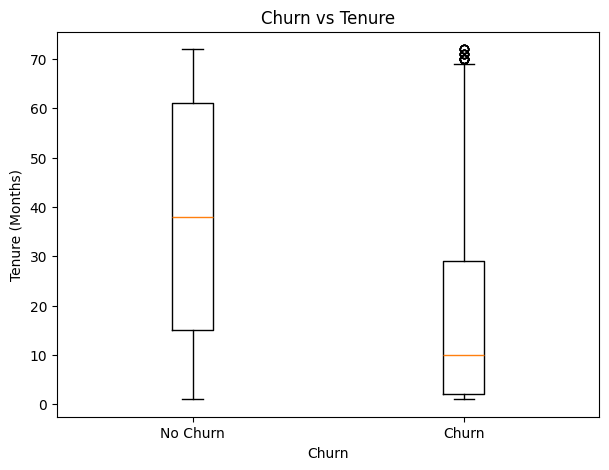

In [26]:
tenure_groups = [
    df.loc[df["Churn"] == 0, "tenure"],
    df.loc[df["Churn"] == 1, "tenure"]
]

plt.figure(figsize=(7,5))
plt.boxplot(tenure_groups, labels=["No Churn", "Churn"])
plt.title("Churn vs Tenure")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")
plt.show()

## Correlation Analysis

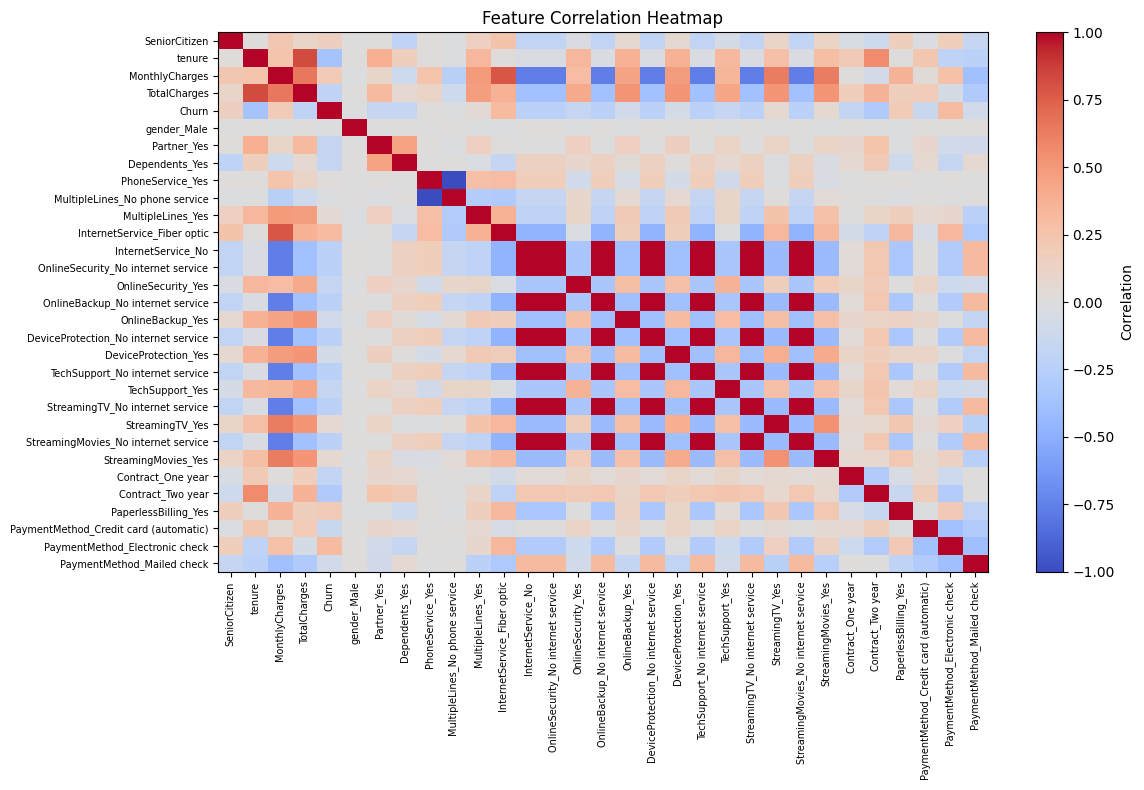

In [27]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))
plt.imshow(corr, aspect="auto", cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90, fontsize=7)
plt.yticks(range(len(corr.columns)), corr.columns, fontsize=7)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

## Feature Scaling

In [28]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")

Feature scaling completed!


## Logistic Regression

In [29]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [30]:
y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

print("Predictions generated!")

Predictions generated!


### Logistic Regression Evaluation

In [31]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
roc_auc_lr = roc_auc_score(y_test, y_prob_lr)

print("Logistic Regression")
print("-------------------------")
print("Accuracy  :", accuracy_lr)
print("Precision :", precision_lr)
print("Recall    :", recall_lr)
print("F1 Score  :", f1_lr)
print("ROC-AUC   :", roc_auc_lr)

Logistic Regression
-------------------------
Accuracy  : 0.8038379530916845
Precision : 0.6475903614457831
Recall    : 0.5748663101604278
F1 Score  : 0.6090651558073654
ROC-AUC   : 0.8356727976766699


In [32]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



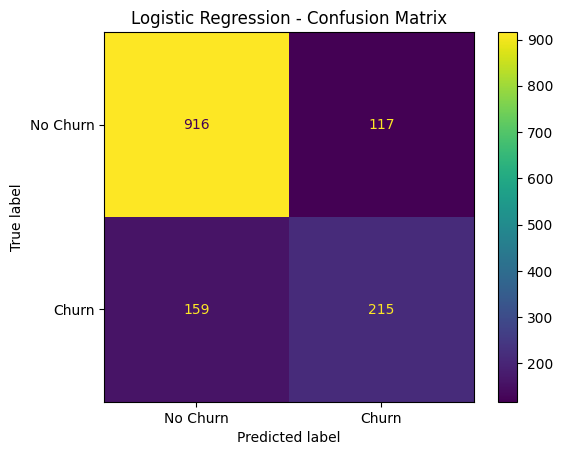

In [33]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=["No Churn", "Churn"]
).plot(values_format="d")

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

## Random Forest

In [34]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [35]:
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest predictions generated!")

Random Forest predictions generated!


### Random Forest Evaluation

In [36]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest")
print("-------------------------")
print("Accuracy  :", accuracy_rf)
print("Precision :", precision_rf)
print("Recall    :", recall_rf)
print("F1 Score  :", f1_rf)
print("ROC-AUC   :", roc_auc_rf)

Random Forest
-------------------------
Accuracy  : 0.7896233120113717
Precision : 0.6258064516129033
Recall    : 0.5187165775401069
F1 Score  : 0.5672514619883041
ROC-AUC   : 0.8164903116927489


In [37]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.63      0.52      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



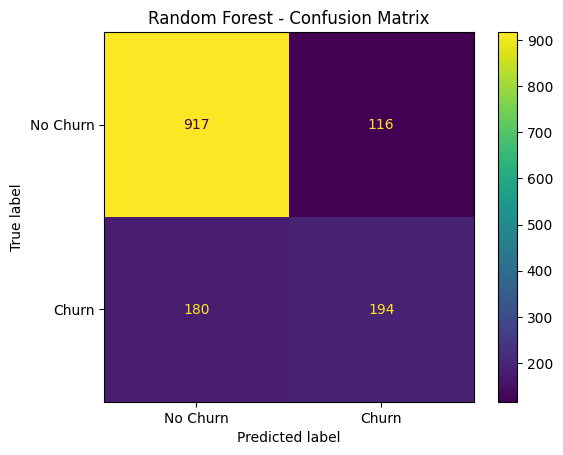

In [38]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["No Churn", "Churn"]
).plot(values_format="d")

plt.title("Random Forest - Confusion Matrix")
plt.show()

## ROC Curve Comparison

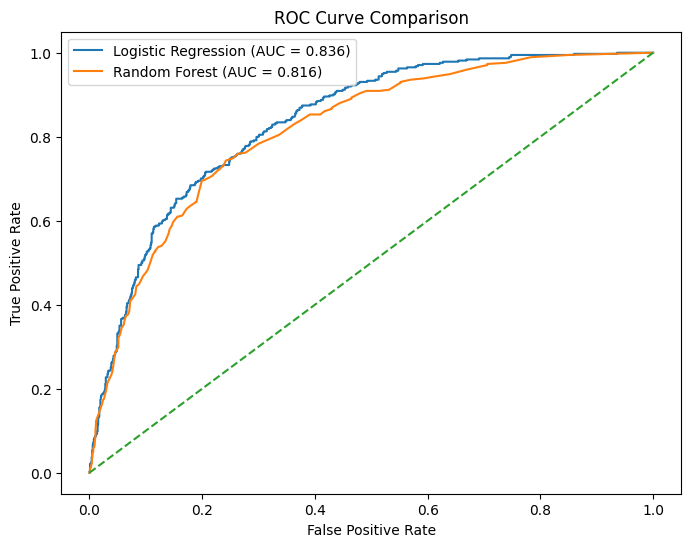

In [39]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(8,6))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {roc_auc_lr:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_rf:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

## Random Forest Feature Importance

In [40]:
importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importance.head(15)

TotalCharges                      0.191435
tenure                            0.171020
MonthlyCharges                    0.168400
InternetService_Fiber optic       0.039481
PaymentMethod_Electronic check    0.037416
Contract_Two year                 0.030529
gender_Male                       0.029332
OnlineSecurity_Yes                0.028157
PaperlessBilling_Yes              0.025536
TechSupport_Yes                   0.024114
Partner_Yes                       0.023682
OnlineBackup_Yes                  0.022932
Contract_One year                 0.022836
SeniorCitizen                     0.021035
Dependents_Yes                    0.019846
dtype: float64

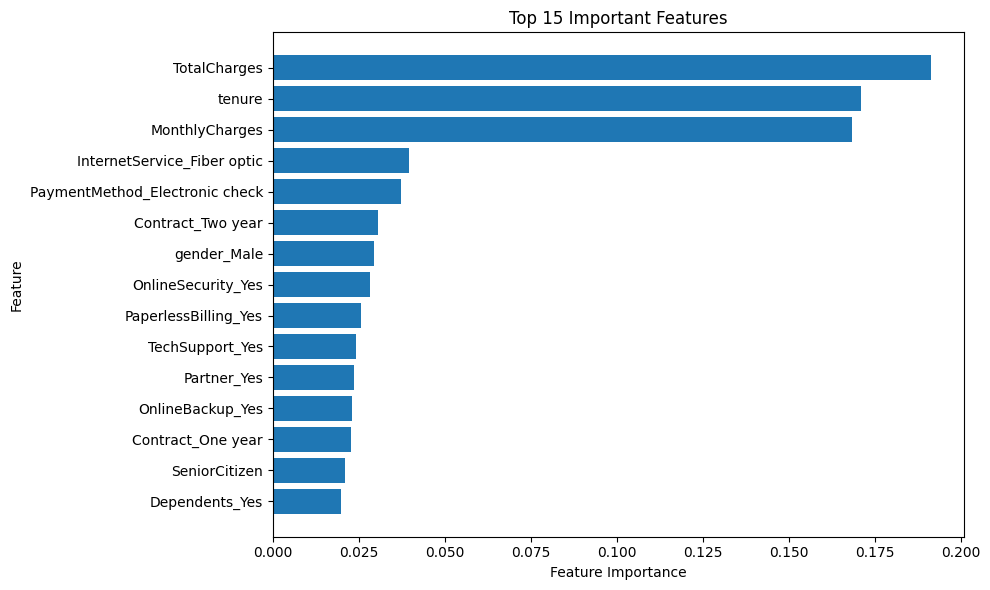

In [41]:
top_importance = importance.head(15).sort_values()

plt.figure(figsize=(10,6))
plt.barh(top_importance.index, top_importance.values)
plt.title("Top 15 Important Features")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## Final Model Comparison

In [42]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [accuracy_lr, accuracy_rf],
    "Precision": [precision_lr, precision_rf],
    "Recall": [recall_lr, recall_rf],
    "F1 Score": [f1_lr, f1_rf],
    "ROC-AUC": [roc_auc_lr, roc_auc_rf]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.803838,0.647590,0.574866,0.609065,0.835673
1,Random Forest,0.789623,0.625806,0.518717,0.567251,0.816490


## Conclusion

This project developed a Customer Churn Prediction system using machine learning.

The dataset was cleaned, missing values were handled, categorical variables were
encoded using one-hot encoding, and exploratory data analysis was performed.
Logistic Regression and Random Forest models were trained and evaluated using
Accuracy, Precision, Recall, F1 Score, ROC-AUC, and Confusion Matrix.

Random Forest feature importance was also analyzed to identify the customer
features that contributed most to the model's predictions.